\textsc{Machine Learning Mini Project 1}

In [575]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-dataset-for-multiple-linear-regression/SalaryMulti.csv


### **Project 1: Comprehensive Regression Analysis**
### Course: Introduction to Machine Learning

This notebook is designed to guide you through a comprehensive regression analysis using various techniques. You will explore different methods, implement regularization techniques, and evaluate the performance of your models using various metrics and computational time.


## Submission Instructions

Once you are finished, follow these steps:

Make sure you have provided the team name, name of team members with IDs.

Restart the kernel and re-run this notebook from beginning to end by going to Kernel > Restart Kernel and Run All Cells. If this process stops halfway through, that means there was an error. Correct the error and repeat Step 1 until the notebook runs from beginning to end. Double check that there is a number next to each code cell and that these numbers are in order. Then, submit your project as follows:

Go to File > Print > Save as PDF. Double check that the entire notebook, from beginning to end, is in this PDF file. Upload the PDF and the notebook to Google Classroom.

### Team Name: **Bhattacharya Brothers**
### Name and ID of Member 1: **Soham Bhattacharya B2430059**
### Name and ID of Member 2: **Darpan Bhattacharya B2430044**

In [576]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [577]:
# Creating empty lists for performance metrics 
Time, MSE, MAE, R2 = [],[],[],[]

# Load the Dataset
**Instruction:** Load the chosen dataset and display its basic information and statistics. You may use any well-known dataset.

In [578]:
# Loading a particular dataset
dataset = pd.read_csv('/kaggle/input/salary-dataset-for-multiple-linear-regression/SalaryMulti.csv')

# Display the first few rows of the dataset
dataset.head()

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687


## **Basic Statistical Analysis**

In [579]:
# Displaying the features
print('Feature names are :',dataset.columns)

Feature names are : Index(['Total Experience', 'Team Lead Experience',
       'Project Manager Experience', 'Certifications', 'Salary'],
      dtype='object')


### Here the target variable is **'Salary'**

In [580]:
# Exploring the feature 'Total Experience'

print('Mean of feature \'Total Experience\':',dataset['Total Experience'].mean())
print('Median of feature \'Total Experience\':',dataset['Total Experience'].median())

mode = dataset['Total Experience'].mode()[0]
print('Mode of feature \'Total Experience\':',mode)

print('Frequency of mode occuring = ',dataset['Total Experience'].value_counts()[mode])

m = min(dataset['Total Experience'])
M = max(dataset['Total Experience'])
print(f'Range of \'Total Experience\' = {m} to {M}')

Mean of feature 'Total Experience': 7.443
Median of feature 'Total Experience': 7.0
Mode of feature 'Total Experience': 12
Frequency of mode occuring =  92
Range of 'Total Experience' = 1 to 14


### We see though mean > median, they are very close to each other, so the total experience is almost symmetric. <br> **We need not apply any kind of feature-scaling to this feature**.

In [581]:
# Exploring the feature 'Team Lead Experience'

print('Mean of feature \'Team Lead Experience\':',dataset['Team Lead Experience'].mean())
print('Median of feature \'Team Lead Experience\':',dataset['Team Lead Experience'].median())

mode = dataset['Team Lead Experience'].mode()[0]
print('Mode of feature \'Team Lead Experience\':',mode)

print('Frequency of mode occuring = ',dataset['Team Lead Experience'].value_counts()[mode])

m = min(dataset['Team Lead Experience'])
M = max(dataset['Team Lead Experience'])
print(f'Range of \'Team Lead Experience\' = {m} to {M}')

Mean of feature 'Team Lead Experience': 3.197
Median of feature 'Team Lead Experience': 2.0
Mode of feature 'Team Lead Experience': 0
Frequency of mode occuring =  245
Range of 'Team Lead Experience' = 0 to 13


### Here, we see that the mean > median, but both the values are almost near to the minimum. <br> So it is likely to be positively skewed. <br> Hence, this feature **should be scaled to a better range**.

In [582]:
# Exploring the feature 'Project Manager Experience'

print('Mean of feature \'Project Manager Experience\':',dataset['Project Manager Experience'].mean())
print('Median of feature \'Project Manager Experience\':',dataset['Project Manager Experience'].median())

mode = dataset['Project Manager Experience'].mode()[0]
print('Mode of feature \'Project Manager Experience\':',mode)

print('Frequency of mode occuring = ',dataset['Project Manager Experience'].value_counts()[mode])

m = min(dataset['Project Manager Experience'])
M = max(dataset['Project Manager Experience'])
print(f'Range of \'Project Manager Experience\' = {m} to {M}')

Mean of feature 'Project Manager Experience': 1.629
Median of feature 'Project Manager Experience': 1.0
Mode of feature 'Project Manager Experience': 0
Frequency of mode occuring =  433
Range of 'Project Manager Experience' = 0 to 13


### Here, we see that the mean > median is quite low in contrast to the range of this feature. <br> Besides, the frequence of mode is quite high and seemingly we **should scale this particular feature.**

In [583]:
# Exploring the feature 'Certifications'

print('Mean of feature \'Certifications\':',dataset['Certifications'].mean())
print('Median of feature \'Certifications\':',dataset['Certifications'].median())

mode = dataset['Certifications'].mode()[0]
print('Mode of feature \'Certifications\':',mode)

print('Frequency of mode occuring = ',dataset['Certifications'].value_counts()[mode])

m = min(dataset['Certifications'])
M = max(dataset['Certifications'])
print(f'Range of \'Certifications\' = {m} to {M}')

Mean of feature 'Certifications': 2.049
Median of feature 'Certifications': 2.0
Mode of feature 'Certifications': 3
Frequency of mode occuring =  227
Range of 'Certifications' = 0 to 4


### We see that the mean > median is decent. <br> Besides, the frequency of mode is quite high and since the range is quite small, we can **avoid scaling this feature.**

## **Feature Scaling**

In [584]:
# importing required modules for the purpose of feature scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

In [585]:
# Defining the Column Transformer

# transformer stores the scaling techniques that are being applied to the list of specific features
transformer = [('num',MinMaxScaler(),['Team Lead Experience','Project Manager Experience'])]

# preprocessor stores the ColumnTransformer object which implements the scaling transformations
preprocessor = ColumnTransformer(transformers=transformer)

In [586]:
column_names = list(dataset.columns[:-1])
column_names

['Total Experience',
 'Team Lead Experience',
 'Project Manager Experience',
 'Certifications']

In [587]:
# Fitting the data to the preprocessor and transforming the features
transformed_dataset = preprocessor.fit_transform(dataset)
# transformed_dataset

# Converting the transformed dataset to dataframe
df = pd.DataFrame(transformed_dataset,columns=['Team Lead Experience','Project Manager Experience'])

In [588]:
# Transformed Features
df

,Team Lead Experience,Project Manager Experience
0,0.153846,0.307692
1,0.000000,0.153846
2,0.307692,0.615385
3,0.230769,0.153846
4,0.076923,0.461538
...,...,...
995,0.076923,0.461538
996,0.230769,0.076923
997,0.769231,0.076923
998,0.384615,0.000000


In [589]:
# Transformed Dataset
Df = pd.concat([dataset['Total Experience'],df,dataset['Certifications'],dataset['Salary']],axis=1)
Df

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,0.153846,0.307692,1,77318.070547
1,4,0.000000,0.153846,3,64951.950980
2,13,0.307692,0.615385,3,106058.185204
3,11,0.230769,0.153846,1,89649.944851
4,8,0.076923,0.461538,3,82206.019687
...,...,...,...,...,...
995,8,0.076923,0.461538,4,90941.688891
996,12,0.230769,0.076923,2,92074.890941
997,14,0.769231,0.076923,2,115914.944924
998,7,0.384615,0.000000,2,82706.285700


In [590]:
# Original Dataset
dataset

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687
...,...,...,...,...,...
995,8,1,6,4,90941.688891
996,12,3,1,2,92074.890941
997,14,10,1,2,115914.944924
998,7,5,0,2,82706.285700


# Data Preprocessing
### **Instruction:** Perform any necessary preprocessing steps, including handling missing values, encoding categorical variables, and scaling features if required.


In [591]:
# Checking for missing values
print('Feature-wise #missing values:')
print(dataset.isna().sum())
print()
print('Total #missing values : ',dataset.isna().sum().sum())

Feature-wise #missing values:
Total Experience              0
Team Lead Experience          0
Project Manager Experience    0
Certifications                0
Salary                        0
dtype: int64

Total #missing values :  0


### We see that the dataset contains no missing values in it.<br>**So there is no need to fill in any missing values.**

In [592]:
# Split the dataset into features (X) and target (y)
X = Df.drop(columns=['Salary'], inplace=False)
y = Df['Salary']

In [593]:
# The feature set X
print(X)

     Total Experience  Team Lead Experience  Project Manager Experience  \
0                   7              0.153846                    0.307692   
1                   4              0.000000                    0.153846   
2                  13              0.307692                    0.615385   
3                  11              0.230769                    0.153846   
4                   8              0.076923                    0.461538   
..                ...                   ...                         ...   
995                 8              0.076923                    0.461538   
996                12              0.230769                    0.076923   
997                14              0.769231                    0.076923   
998                 7              0.384615                    0.000000   
999                10              0.461538                    0.153846   

     Certifications  
0                 1  
1                 3  
2                 3  
3          

In [594]:
# The target variable y
print(y)

0       77318.070547
1       64951.950980
2      106058.185204
3       89649.944851
4       82206.019687
           ...      
995     90941.688891
996     92074.890941
997    115914.944924
998     82706.285700
999     85347.167601
Name: Salary, Length: 1000, dtype: float64


In [595]:
# Split the data into training and test sets (e.g., 80% training, 20% testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [596]:
# Checking whether the dataset has been split correctly or not

print('X_train shape =',X_train.shape)
print('X_test shape =',X_test.shape)
print('y_train shape =',y_train.shape)
print('y_test shape =',y_test.shape)

X_train shape = (800, 4)
X_test shape = (200, 4)
y_train shape = (800,)
y_test shape = (200,)


# Simple Linear Regression
### **Instruction:** Implement a simple linear regression model using scikit-learn.


In [597]:
# Importing the linear model to execute LinearRegression
from sklearn.linear_model import LinearRegression

# Define the linear regression model
start_time = time.time()
model_lr = LinearRegression()
end_time = time.time()

Time.append(end_time-start_time)


# Fit the model on the training data
model_lr.fit(X_train, y_train)

LinearRegression()

In [598]:
# Printing the coefficients of the model
print('Coefficients of the Linear Regression Model =',model_lr.coef_)
print('Intercept of the Linear Regression Model =',model_lr.intercept_)
# Predict on the test data
y_pred = model_lr.predict(X_test)
print('\nPredictions based on X_test =',y_pred)

Coefficients of the Linear Regression Model = [ 2988.17486511 24676.22400119 12671.14343315   371.32169738]
Intercept of the Linear Regression Model = 50769.34540329708

Predictions based on X_test = [109210.38407843  76699.34791527  72198.61195967  98477.27714231
 100823.8207706   53757.52026841  62978.06611404  68634.32975189
  90062.13725619  71595.23031604 118765.30430558 108211.71943336
  95334.09318484  74416.86912906 110764.50775902  84458.56827543
  82267.42863225  65015.49894219  58463.0418693   91743.99572818
  54871.48536056 100156.37428489  65015.49894219  64207.33165328
 100593.21987643  63349.38781142 104824.94856991  60129.15300007
  54871.48536056  55242.80705794  82457.92598839  95154.72789568
  61683.27668065  75790.16846841  76852.89795555 106699.15834288
  73674.2257343   95116.47830248  78189.24997904  93219.6095028
  84625.10432752  66518.38701777  79098.4294259   74045.54743168
 103632.63034655  69159.20148955  71827.29026229  67683.58771493
  77942.90174365  578

In [599]:
# Printing range of the target variable
print('Range of Salary list =',Df.Salary.min(),'-',Df.Salary.max())

Range of Salary list = 42298.0568266786 - 126221.71673508518


### **MAE** <br> If MAE is as close as zero, it can be considered a good fit. It also depends on the range of the target variable, which typically describes the extent of leniency in the value determination.<br>
### **MSE** <br> If MSE is as close as zero, it can be considered a good fit.<br>
### **R^2** <br> If R^2 is as close as 1, it is considerd a good fit. Otherwise there is scope of further improvement.

In [600]:
# Calculate performance metrics [MSE, MAE, R^2]
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Print the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  3733.830769337311
Root Mean Squared Error =  4562.8311360125535
R-squared Error =  0.940614842359922


**We see that R^2 value is more than 0.9, and hence we can ascertain that the model is a good model for this prediction.**

## **Feature Plots**

### **Feature vs Target scatter plots**

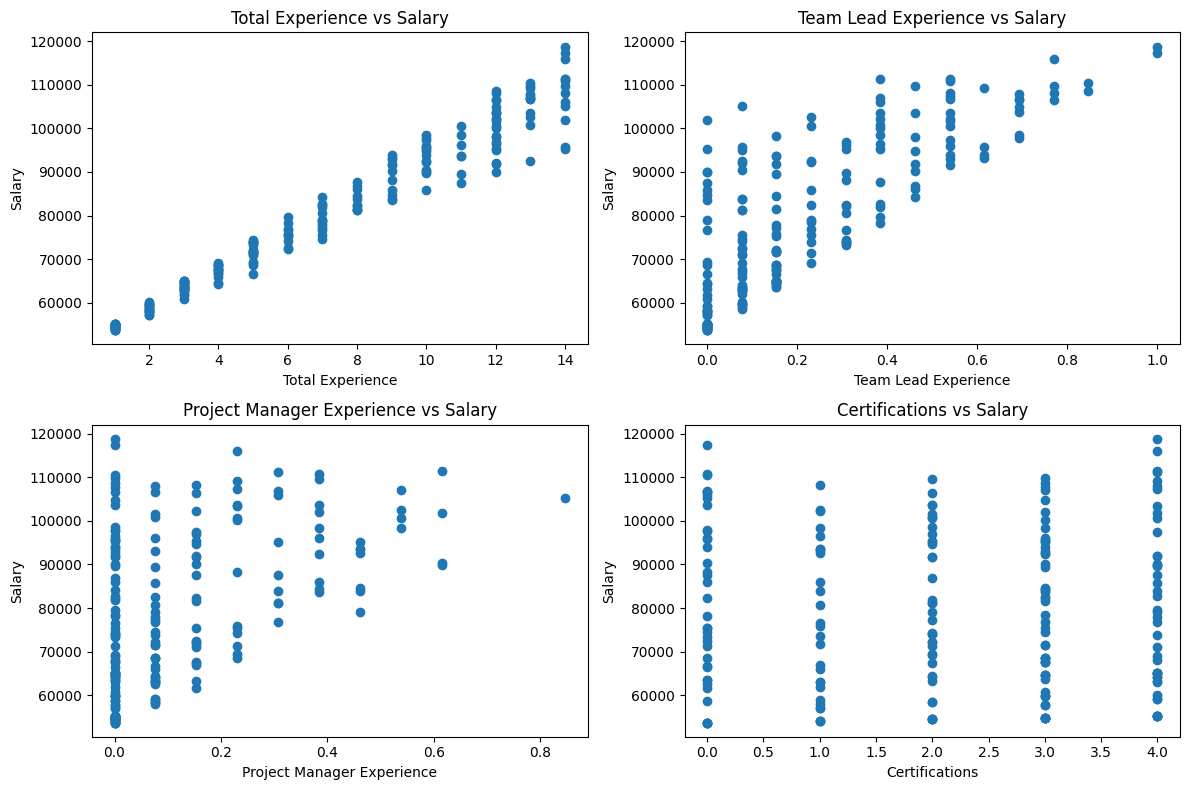

In [601]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot each feature against the target
features = list(X_test.columns)
target = 'Salary'

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    plt.scatter(X_test[feature], y_pred)
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()


### **Pairplots of features**

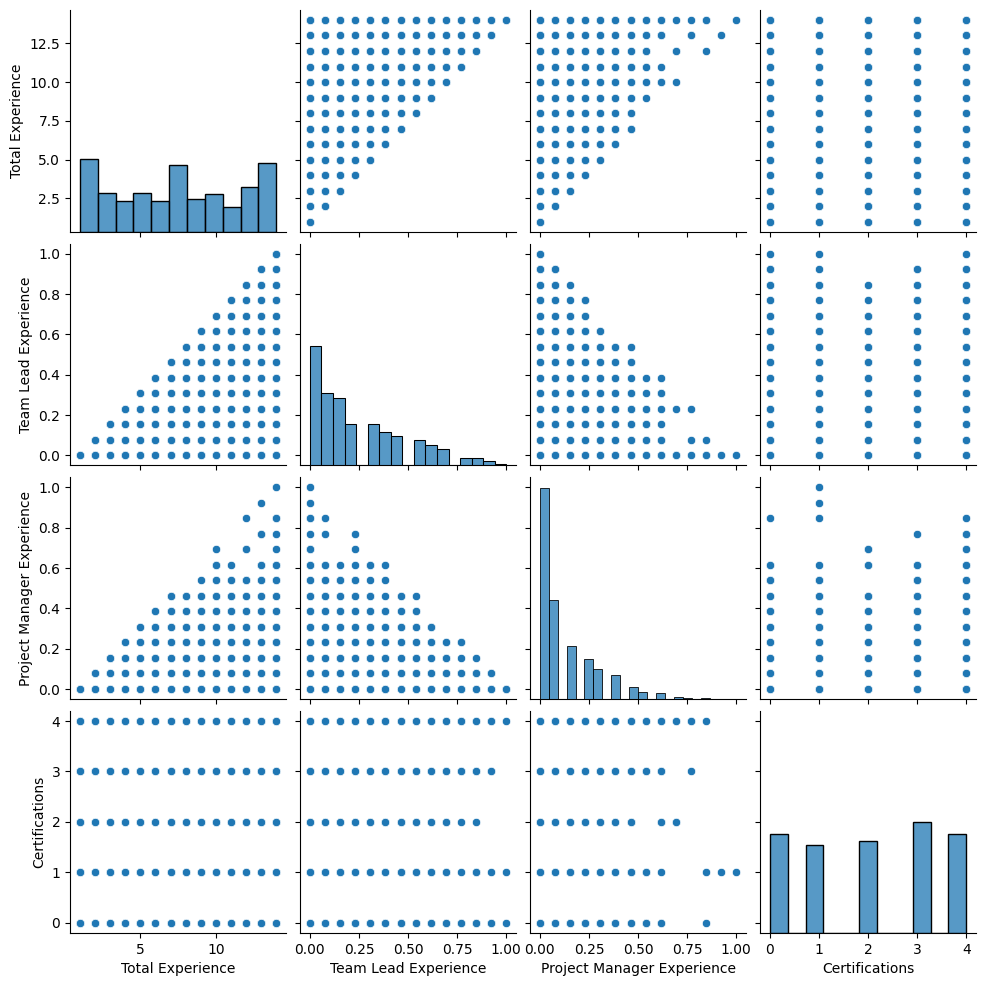

In [602]:
import seaborn as sns
import warnings

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create a pairplot
sns.pairplot(X)
plt.show()

### **Correlation matrix with a heatmap**

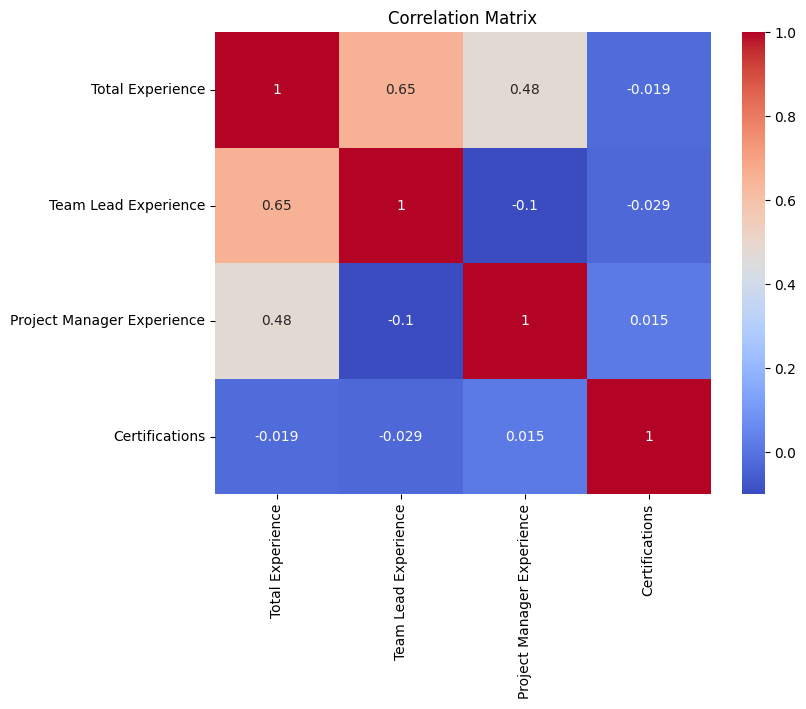

In [603]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


### **Residual Plots**

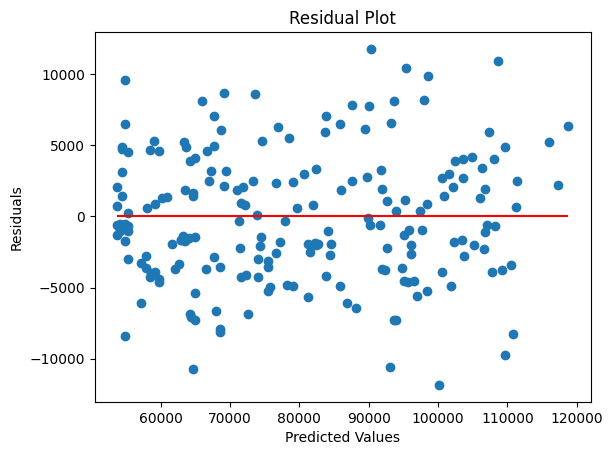

In [604]:
# Residuals
residuals = y_test - y_pred

# Scatter plot of residuals
plt.scatter(y_pred, residuals)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# Polynomial Regression
**Instruction:** Implement polynomial regression for degrees 2, 3, and 4.

In [605]:
# Define polynomial features
from sklearn.preprocessing import PolynomialFeatures

In [606]:
# Printing the transformed dataset
Df

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,0.153846,0.307692,1,77318.070547
1,4,0.000000,0.153846,3,64951.950980
2,13,0.307692,0.615385,3,106058.185204
3,11,0.230769,0.153846,1,89649.944851
4,8,0.076923,0.461538,3,82206.019687
...,...,...,...,...,...
995,8,0.076923,0.461538,4,90941.688891
996,12,0.230769,0.076923,2,92074.890941
997,14,0.769231,0.076923,2,115914.944924
998,7,0.384615,0.000000,2,82706.285700


## # **Degree 2**

In [607]:
degree = 2
poly2 = PolynomialFeatures(degree=degree)

# Transforming the dataset for polynomial features
start_time = time.time()
Df_poly2 = poly2.fit_transform(Df.drop(columns=['Salary']))
end_time = time.time()

Time.append(end_time-start_time)

In [608]:
Df_poly2.shape

(1000, 15)

In [609]:
# Split the transformed data into training and test sets
X_poly2 = Df_poly2#.drop(columns=['Salary'])
y_poly2 = Df.Salary

X_train_poly2, X_test_poly2, y_train_poly2, y_test_poly2 = train_test_split(X_poly2, y_poly2, test_size=0.2, random_state=42)

In [610]:
# Fit the linear model on polynomial features
model_poly2 = LinearRegression()

model_poly2.fit(X_train_poly2, y_train_poly2)

LinearRegression()

In [611]:
# Predict and evaluate performance
y_pred_poly2 = model_poly2.predict(X_test_poly2)

# Calculate performance metrics for polynomial regression

mae_poly2 = mean_absolute_error(y_test_poly2, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test_poly2, y_pred_poly2)
r2_poly2 = r2_score(y_test_poly2, y_pred_poly2)
rmse_poly2 = mse_poly2**0.5

# Print the metrics for polynomial regression

print('Mean Absolute Error = ',mae_poly2)
print('Root Mean Squared Error = ',rmse_poly2)
print('R-squared Error = ',r2_poly2)

MSE.append(mse_poly2)
MAE.append(mae_poly2)
R2.append(r2_poly2)

Mean Absolute Error =  3751.7507691069227
Root Mean Squared Error =  4626.411161924845
R-squared Error =  0.9389483262190852


## # **Degree 3**

In [612]:
degree = 3
poly3 = PolynomialFeatures(degree=degree)

# Transforming the dataset for polynomial features
start_time = time.time()
Df_poly3 = poly3.fit_transform(Df.drop(columns=['Salary']))
end_time = time.time()

Time.append(end_time-start_time)

In [613]:
Df_poly3.shape

(1000, 35)

In [614]:
# Split the transformed data into training and test sets
X_poly3 = Df_poly3
y_poly3 = Df.Salary

X_train_poly3, X_test_poly3, y_train_poly3, y_test_poly3 = train_test_split(X_poly3, y_poly3, test_size=0.2, random_state=42)

In [615]:
3# Fit the linear model on polynomial features
model_poly3 = LinearRegression()

model_poly3.fit(X_train_poly3, y_train_poly3)

LinearRegression()

In [616]:
# Predict and evaluate performance
y_pred_poly3 = model_poly3.predict(X_test_poly3)

# Calculate performance metrics for polynomial regression

mae_poly3 = mean_absolute_error(y_test_poly3, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test_poly3, y_pred_poly3)
r2_poly3 = r2_score(y_test_poly3, y_pred_poly3)
rmse_poly3 = mse_poly3**0.5

# Print the metrics for polynomial regression

print('Mean Absolute Error = ',mae_poly3)
print('Root Mean Squared Error = ',rmse_poly3)
print('R-squared Error = ',r2_poly3)

MSE.append(mse_poly3)
MAE.append(mae_poly3)
R2.append(r2_poly3)

Mean Absolute Error =  3813.6790839546607
Root Mean Squared Error =  4735.379905393355
R-squared Error =  0.9360384801976465


## # **Degree 4**

In [617]:
degree = 4
poly4 = PolynomialFeatures(degree=degree)

# Transforming the dataset for polynomial features
start_time = time.time()
Df_poly4 = poly4.fit_transform(Df.drop(columns=['Salary']))
end_time = time.time()

Time.append(end_time-start_time)

In [618]:
Df_poly4.shape

(1000, 70)

In [619]:
# Split the transformed data into training and test sets
X_poly4 = Df_poly4
y_poly4 = Df.Salary

X_train_poly4, X_test_poly4, y_train_poly4, y_test_poly4 = train_test_split(X_poly4, y_poly4, test_size=0.2, random_state=42)

In [620]:
# Fit the linear model on polynomial features
model_poly4 = LinearRegression()

model_poly4.fit(X_train_poly4, y_train_poly4)

LinearRegression()

In [621]:
# Predict and evaluate performance
y_pred_poly4 = model_poly4.predict(X_test_poly4)

# Calculate performance metrics for polynomial regression

mae_poly4 = mean_absolute_error(y_test_poly4, y_pred_poly4)
mse_poly4 = mean_squared_error(y_test_poly4, y_pred_poly4)
r2_poly4 = r2_score(y_test_poly4, y_pred_poly4)
rmse_poly4 = mse_poly4**0.5

# Print the metrics for polynomial regression

print('Mean Absolute Error = ',mae_poly4)
print('Root Mean Squared Error = ',rmse_poly4)
print('R-squared Error = ',r2_poly4)

MSE.append(mse_poly4)
MAE.append(mae_poly4)
R2.append(r2_poly4)

Mean Absolute Error =  3880.5011291587925
Root Mean Squared Error =  4901.3344836694905
R-squared Error =  0.9314767736231301


### Remarks: <br> As we increase the degree involved in *Polynomial Regression* for this dataset, we find that the efficiency of the model reduces, i.e., $R^2$ slowly reduces from 0.94 to a lower value.

# Gradient Descent Methods
### **Instruction:** Implement batch, stochastic, and mini-batch gradient descent for linear regression.


## **Batch Gradient Descent Method**

In [622]:
# Example function for batch gradient descent.
# Return theta and history (a list that stores cost for each epoch)
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000, print_flag = 1):

    m, n = X.shape  # m: number of samples, n: number of features
    theta = np.zeros(n)  # Initialize theta to zero (n x 1)
    history = []  # To record the cost at each iteration
    #print(n)
    for epoch in range(epochs):
        # Compute the predictions
        predictions = X.dot(theta)

        # Compute the error
        error = predictions - y

        # Compute the gradient
        gradients = (2/m) * X.T.dot(error)

        # Update the parameters theta
        theta = theta - learning_rate * gradients

        # Compute the cost (mean squared error)
        cost = (1/m) * np.sum(error**2)
        history.append(cost)

        # Optional: print the cost at every 100th epoch for monitoring
        if epoch % 100 == 0 and print_flag:
            print(f"Epoch {epoch}: Cost {cost}")

    
    return theta, history

# Add similar functions for stochastic and mini-batch gradient descent
# Run them and output the performance

In [623]:
print(f"X_train = {X_train}\n y_train = {y_train}")

start_time = time.time()
bgd = batch_gradient_descent(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

X_train =      Total Experience  Team Lead Experience  Project Manager Experience  \
29                  1              0.000000                    0.000000   
535                 8              0.000000                    0.000000   
695                 9              0.153846                    0.076923   
557                 8              0.538462                    0.000000   
836                 9              0.615385                    0.000000   
..                ...                   ...                         ...   
106                13              0.846154                    0.076923   
270                14              0.230769                    0.000000   
860                 4              0.000000                    0.230769   
435                 1              0.000000                    0.000000   
102                 9              0.461538                    0.153846   

     Certifications  
29                3  
535               0  
695               2  
5

In [624]:
# set of theta values fetched from Batch Gradient Descent
bgd[0]

Total Experience              7595.826400
Team Lead Experience          4307.205776
Project Manager Experience   -4578.810248
Certifications                8115.189968
dtype: float64

In [625]:
# Cost value received at the last executed epoch
bgd[1][-1]

410874953.60155356

In [626]:
# Statistics of the cost function
pd.DataFrame(bgd[1]).describe()

,0
count,1.000000e+03
mean,4.225499e+08
std,2.192752e+08
min,4.108750e+08
25%,4.113646e+08
50%,4.121085e+08
75%,4.132486e+08
max,7.021607e+09


### Plotting the corresponding cost function

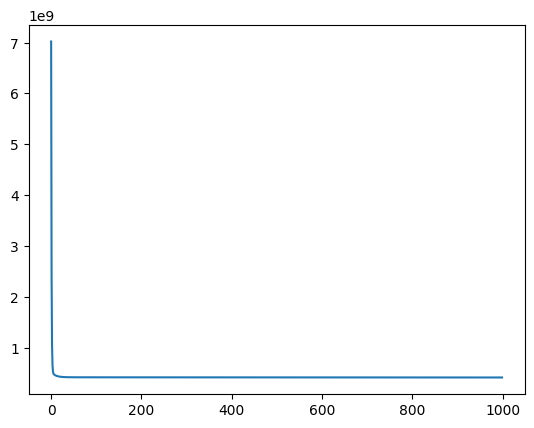

In [627]:
plt.plot(bgd[1])
plt.show()

In [628]:
# Predict using the theta derived using Batch-Gradient-Descent Algorithm
y_pred_bgd = X_test.dot(bgd[0])

In [629]:
# Calculate and print the performance metrics

mae = mean_absolute_error(y_test, y_pred_bgd)
mse = mean_squared_error(y_test, y_pred_bgd)
r2 = r2_score(y_test, y_pred_bgd)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  16702.131729347715
Root Mean Squared Error =  20596.454200548364
R-squared Error =  -0.21002415994771884


## **Stochastic Gradient Descent**

In [630]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100, print_flag = 1):
    m, n = X.shape  # m: number of samples, n: number of features
    theta = np.random.randn(n)  # Initialize parameters randomly
    history = []  # To record the cost at each iteration
    
    for epoch in range(epochs):
        done = []
        
        random_index = np.random.randint(m)
        if(random_index in done):
            continue
        
        done+=[random_index]
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        # Compute the prediction
        prediction = np.dot(xi, theta)

        # Compute the error
        error = prediction - yi

        # Compute the gradient
        gradients = 2 * xi.T.dot(error)

        # Update the parameters
        theta = theta - learning_rate * gradients

        # Compute the cost (mean squared error)
        cost = (1/m) * np.sum(error**2)
        history.append(cost)

        # Optional: print the cost at every 100th epoch for monitoring
        if epoch % 10 == 0 and print_flag:
            print(f"Epoch {epoch}: Cost {cost}")

        
        # Optionally, reduce the learning rate as epochs increase (learning rate scheduling)
        learning_rate = learning_rate * 0.95
    
    return theta, history

In [631]:
print(f"X_train = {X_train}\n y_train = {y_train}")

start_time = time.time()
sgd = stochastic_gradient_descent(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

X_train =      Total Experience  Team Lead Experience  Project Manager Experience  \
29                  1              0.000000                    0.000000   
535                 8              0.000000                    0.000000   
695                 9              0.153846                    0.076923   
557                 8              0.538462                    0.000000   
836                 9              0.615385                    0.000000   
..                ...                   ...                         ...   
106                13              0.846154                    0.076923   
270                14              0.230769                    0.000000   
860                 4              0.000000                    0.230769   
435                 1              0.000000                    0.000000   
102                 9              0.461538                    0.153846   

     Certifications  
29                3  
535               0  
695               2  
5

In [632]:
# Set of theta values fetched using Stochastic Gradient Descent
sgd[0]

Total Experience              8660.401832
Team Lead Experience          1937.445826
Project Manager Experience    -453.793164
Certifications                3992.136973
dtype: float64

In [633]:
# Cost value received at the last executed epoch
sgd[1][-1]

200390.9238253547

In [634]:
# Statistics of the cost function
pd.DataFrame(sgd[1]).describe()

,0
count,1.000000e+02
mean,1.574475e+06
std,4.002055e+06
min,1.334456e+02
25%,1.344903e+05
50%,3.896551e+05
75%,1.348904e+06
max,2.721407e+07


### Plotting the corresponding cost function

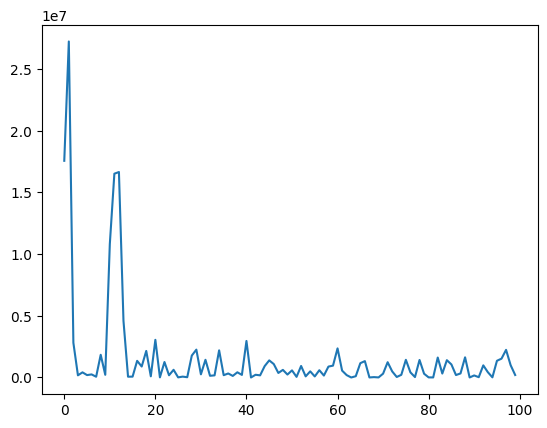

In [635]:
plt.plot(sgd[1])
plt.show()

In [636]:
# Predict using the normal equation
y_pred_sgd = X_test.dot(sgd[0])

In [637]:
# Calculate and print the performance metrics

mae = mean_absolute_error(y_test, y_pred_sgd)
mse = mean_squared_error(y_test, y_pred_sgd)
r2 = r2_score(y_test, y_pred_sgd)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  19097.826875917846
Root Mean Squared Error =  22696.938752118967
R-squared Error =  -0.4694123721575745


## **Mini-Batch Gradient Descent**

In [638]:
import random

def mini_batch_gradient_descent(X, y, learning_rate=0.01, epochs=100, batch_size = 100):
    m, n = X.shape  # m: number of samples, n: number of features
    theta = np.random.randn(n)  # Initialize parameters randomly
    history = []  # To record the cost at each iteration
    
    for epoch in range(epochs):
        
        i = random.randint(0,m-batch_size)
    
        now_gd = batch_gradient_descent(X_train[i:i+batch_size], y_train[i:i+batch_size], learning_rate, epochs=1, print_flag = 0)
        history.append(now_gd[1][-1])
        theta = now_gd[0]
        
        learning_rate*=0.90
        
        if epoch%10==0:
            print(f"Epoch {epoch}: Cost {history[-1]}")
    
    
    return theta, history

In [639]:
print(f"X_train = {X_train}\n y_train = {y_train}")

start_time = time.time()
mbgd = mini_batch_gradient_descent(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

X_train =      Total Experience  Team Lead Experience  Project Manager Experience  \
29                  1              0.000000                    0.000000   
535                 8              0.000000                    0.000000   
695                 9              0.153846                    0.076923   
557                 8              0.538462                    0.000000   
836                 9              0.615385                    0.000000   
..                ...                   ...                         ...   
106                13              0.846154                    0.076923   
270                14              0.230769                    0.000000   
860                 4              0.000000                    0.230769   
435                 1              0.000000                    0.000000   
102                 9              0.461538                    0.153846   

     Certifications  
29                3  
535               0  
695               2  
5

In [640]:
# Set of theta values fetched on implementation of Mini-Batch-Gradient-Descent
mbgd[0]

Total Experience              0.369216
Team Lead Experience          0.012463
Project Manager Experience    0.006608
Certifications                0.091738
dtype: float64

In [641]:
# Cost value received at the last executed epoch
mbgd[1][-1]

6640072290.139612

In [642]:
# Statistics of the cost function
pd.DataFrame(mbgd[1]).describe()

,0
count,1.000000e+02
mean,7.015401e+09
std,2.778693e+08
min,6.425452e+09
25%,6.835541e+09
50%,7.079121e+09
75%,7.189493e+09
max,7.598771e+09


### Plotting the corresponding cost function

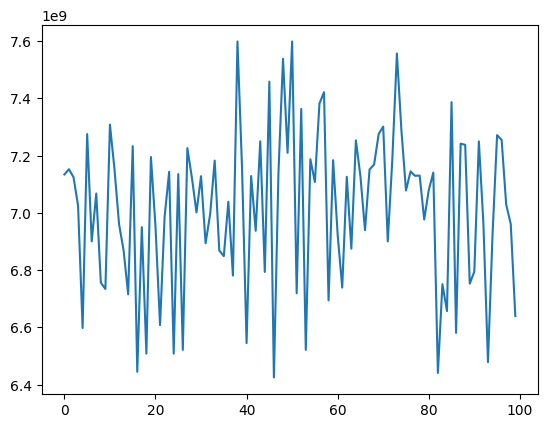

In [643]:
plt.plot(mbgd[1])
plt.show()

In [644]:
# Predict using the normal equation
y_pred_mbgd = X_test.dot(mbgd[0])

In [645]:
# Calculate and print the performance metrics

mae = mean_absolute_error(y_test, y_pred_mbgd)
mse = mean_squared_error(y_test, y_pred_mbgd)
r2 = r2_score(y_test, y_pred_mbgd)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  79760.4216297881
Root Mean Squared Error =  81928.33598278118
R-squared Error =  -18.145970661283673


Here, we see that $R^2$ score is extremely low and negative, and so the models using the above Batch Gradient Descent algorithms are performing worse than the baseline model.

# Regularization Techniques (Ridge,  Lasso, Elastic Net Regression and Early Stopping)
### **Instruction:** Implement Ridge, Lasso regression, Elastic Net Regression, and Early Stopping using scikit-learn and compare the results.


## **Lasso Regression**

In [646]:
# Lasso Regression

from sklearn.linear_model import Lasso

# Apply Lasso Regression
lasso_reg = Lasso(alpha = 0.1) # alpha is equivalent to the regularization parameter

# Fitting the data into the Lasso model
start_time = time.time()
lasso_reg.fit(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

In [647]:
# Predictions
y_lasso_pred = lasso_reg.predict(X_test)

In [648]:
from sklearn.metrics import mean_squared_error

# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_lasso_pred)
mse = mean_squared_error(y_test, y_lasso_pred)
r2 = r2_score(y_test, y_lasso_pred)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)
# Print results
print("Lasso Coefficients:", lasso_reg.coef_)
print("Intercept:", lasso_reg.intercept_)

Mean Absolute Error =  3733.8847244560106
Root Mean Squared Error =  4562.872648378259
R-squared Error =  0.9406137617897574
Lasso Coefficients: [ 2988.74050397 24667.38168552 12659.40164745   371.29929161]
Intercept: 50768.79898706264


## **Ridge Regression**

In [649]:
# Ridge Regression

from sklearn.linear_model import Ridge

# Apply Lasso Regression
ridge_reg = Ridge(alpha = 0.1) # alpha is equivalent to the regularization parameter

# Fitting the data into the Lasso model
start_time = time.time()
ridge_reg.fit(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

In [650]:
# Predictions
y_ridge_pred = ridge_reg.predict(X_test)

In [651]:
from sklearn.metrics import mean_squared_error

# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_ridge_pred)
mse = mean_squared_error(y_test, y_ridge_pred)
r2 = r2_score(y_test, y_ridge_pred)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

# Print results
print("Ridge Coefficients:", ridge_reg.coef_)
print("Intercept:", ridge_reg.intercept_)

Mean Absolute Error =  3735.112517597495
Root Mean Squared Error =  4563.829429560394
R-squared Error =  0.9405888539754116
Ridge Coefficients: [ 3000.58891017 24469.30024109 12434.7945371    371.79949894]
Intercept: 50755.9232483335


## **Elastic Net Regression**

In [652]:
# ElasticNet Regression

from sklearn.linear_model import ElasticNet

# Apply Lasso Regression
elasticNet_reg = ElasticNet(alpha = 0.1) # alpha is equivalent to the regularization parameter

# Fitting the data into the Lasso model
start_time = time.time()
elasticNet_reg.fit(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

In [653]:
# Predictions
y_elasticNet_pred = elasticNet_reg.predict(X_test)

In [654]:
from sklearn.metrics import mean_squared_error

# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_elasticNet_pred)
mse = mean_squared_error(y_test, y_elasticNet_pred)
r2 = r2_score(y_test, y_elasticNet_pred)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

# Print results
print("ElasticNet Coefficients:", elasticNet_reg.coef_)
print("Intercept:", elasticNet_reg.intercept_)

Mean Absolute Error =  4187.096813445808
Root Mean Squared Error =  5208.430233988108
R-squared Error =  0.9226210515989918
ElasticNet Coefficients: [3881.9567423  7460.64503387 -205.86158035  380.57478891]
Intercept: 49911.45956891707


## **Early Stopping**

In [655]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor

In [656]:
# Parameters
learning_rate = 0.02
epochs = 1000
patience = 20
min_delta = 0.0001

In [657]:
# Initialize model
model = SGDRegressor(learning_rate='constant', eta0=learning_rate, max_iter=1, warm_start=True, tol=None)

In [658]:
# Early stopping variables
best_val_loss = float('inf')
best_weights = None
no_improvement_count = 0

In [659]:
# Training with early stopping
import time

time_es = 0
for epoch in range(epochs):
    # Train on the training set
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    time_es = end_time-start_time
    
    # Evaluate on the validation set
    y_es_pred = model.predict(X_test)
    curr_loss = mean_squared_error(y_test, y_es_pred)

    print(f"Epoch {epoch+1}/{epochs}, Validation MSE: {curr_loss}")

    # Check for improvement
    if curr_loss < best_val_loss - min_delta:
        best_val_loss = curr_loss
        best_weights = model.coef_.copy()  # Save the best weights
        no_improvement_count = 0
    else:
        no_improvement_count += 1

    # Stop if no improvement for 'patience' epochs
    if no_improvement_count >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/1000, Validation MSE: 1.788547117848814e+17
Epoch 2/1000, Validation MSE: 1.478229802774865e+19
Epoch 3/1000, Validation MSE: 8.616273051449888e+21
Epoch 4/1000, Validation MSE: 1.4996692147128864e+20
Epoch 5/1000, Validation MSE: 1.8653559183970003e+20
Epoch 6/1000, Validation MSE: 2.773744355397893e+21
Epoch 7/1000, Validation MSE: 2.075887550898545e+20
Epoch 8/1000, Validation MSE: 3.0703196982188114e+23
Epoch 9/1000, Validation MSE: 4.730472038094351e+19
Epoch 10/1000, Validation MSE: 4.021738006686673e+21
Epoch 11/1000, Validation MSE: 1.938898709288203e+22
Epoch 12/1000, Validation MSE: 3.6421535759278775e+20
Epoch 13/1000, Validation MSE: 1.1960481403917471e+20
Epoch 14/1000, Validation MSE: 1.2108035085633267e+23
Epoch 15/1000, Validation MSE: 7.45422317638568e+22
Epoch 16/1000, Validation MSE: 4.722674035989547e+20
Epoch 17/1000, Validation MSE: 8.943984211328336e+19
Epoch 18/1000, Validation MSE: 5.347945607223829e+21
Epoch 19/1000, Validation MSE: 1.7575589004625104e

In [660]:
# Load the best weights
model.coef_ = best_weights

Time.append(time_es)

# Evaluate on the test set
y_es_pred = model.predict(X_test)

In [661]:
# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_es_pred)
mse = mean_squared_error(y_test, y_es_pred)
r2 = r2_score(y_test, y_es_pred)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  13966267414.190529
Root Mean Squared Error =  13967454315.660168
R-squared Error =  -556472413953.899


# Normal Equation
### **Instruction:** Implement the normal equation method for linear regression.

In [662]:
# Define Normal equation. Inputs: X and y, Output: theta
import numpy as np
def normal_equation(X, y):
    # Put your code and output accordingly
    
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [663]:
# Use the normal equation to find theta
start_time = time.time()
theta_ne = normal_equation(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

In [664]:
# Predict using the normal equation
y_pred_ne = X_test.dot(theta_ne)

In [665]:
# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_pred_ne)
mse = mean_squared_error(y_test, y_pred_ne)
r2 = r2_score(y_test, y_pred_ne)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  16661.366936622355
Root Mean Squared Error =  20599.47080489473
R-squared Error =  -0.21037863178158878


# Implement Linear Regression using SVD

In [666]:
# Define SVD equation. Inputs: X and y, Output: theta

import numpy as np

def svd_equation(X, y):
    # Put your code and output accordingly
    # Compute SVD of X
    U, Sigma, VT = np.linalg.svd(X, full_matrices=False)

    # Compute the pseudo-inverse of Sigma
    Sigma_inv = np.diag(1/Sigma)

    # Calculate theta
    theta = VT.T.dot(Sigma_inv).dot(U.T).dot(y)

    print("Theta (parameters):", theta)

    return theta

In [667]:
# Use the svd equation to find theta
start_time = time.time()
theta_svd = svd_equation(X_train, y_train)
end_time = time.time()

Time.append(end_time-start_time)

Theta (parameters): [  7761.33045889   3657.8201198  -12818.13170628   8106.45557543]


In [668]:
# Predict using SVD
y_pred_svd = X_test.dot(theta_svd)

In [669]:
# Calculating Performance Metrics
mae = mean_absolute_error(y_test, y_pred_svd)
mse = mean_squared_error(y_test, y_pred_svd)
r2 = r2_score(y_test, y_pred_svd)
rmse = mse**0.5

print('Mean Absolute Error = ',mae)
print('Root Mean Squared Error = ',rmse)
print('R-squared Error = ',r2)

MSE.append(mse)
MAE.append(mae)
R2.append(r2)

Mean Absolute Error =  16661.36693662236
Root Mean Squared Error =  20599.47080489473
R-squared Error =  -0.21037863178158878


# Performance Metrics and Computational Analysis
### **Instruction:** Compare the performance and computational time of all models implemented.

In [670]:
# Listing out the models used in this project file
list_of_models = ['SimpleLinearRegression','PolynomialRegressionDegree2','PolynomialRegressionDegree3','PolynomialRegressionDegree4','BatchGradientDescent','StochasticGradientDescent','MiniBatchGradientDescent','LassoRegression','RidgeRegression','ElasticNetRegression','EarlyStopping','NormalEquation','SVD']
list_of_models

['SimpleLinearRegression',
 'PolynomialRegressionDegree2',
 'PolynomialRegressionDegree3',
 'PolynomialRegressionDegree4',
 'BatchGradientDescent',
 'StochasticGradientDescent',
 'MiniBatchGradientDescent',
 'LassoRegression',
 'RidgeRegression',
 'ElasticNetRegression',
 'EarlyStopping',
 'NormalEquation',
 'SVD']

In [671]:
# Converting the list of performance metrics of each model,into a dataframe
time_df = pd.DataFrame(Time)
mse_df = pd.DataFrame(MSE)
mae_df = pd.DataFrame(MAE)
r2_df = pd.DataFrame(R2)

In [672]:
# Printing the list of each performance metrics

print('Time =',Time)
print()
print('MSE =',MSE)
print()
print('MAE =',MAE)
print()
print('R2 =',R2)

Time = [0.00010085105895996094, 0.008753299713134766, 0.01027059555053711, 0.007493019104003906, 1.829671859741211, 0.16376519203186035, 0.15477871894836426, 0.003470897674560547, 0.003064870834350586, 0.0036351680755615234, 0.0020112991333007812, 0.003326416015625, 0.001966714859008789]

MSE = [20819427.97576561, 21403680.239182793, 22423822.848403186, 24023079.720807675, 424213925.6352864, 515151028.71743965, 6712252236.907478, 20819806.80531843, 20828539.06212155, 27127745.502321415, 1.9508978006005386e+20, 424338197.44171023, 424338197.44171023]

MAE = [3733.830769337311, 3751.7507691069227, 3813.6790839546607, 3880.5011291587925, 16702.131729347715, 19097.826875917846, 79760.4216297881, 3733.8847244560106, 3735.112517597495, 4187.096813445808, 13966267414.190529, 16661.366936622355, 16661.36693662236]

R2 = [0.940614842359922, 0.9389483262190852, 0.9360384801976465, 0.9314767736231301, -0.21002415994771884, -0.4694123721575745, -18.145970661283673, 0.9406137617897574, 0.9405888539

## Index Reference of models for graph-plots
0. 'SimpleLinearRegression'
1. 'PolynomialRegressionDegree2'
2. 'PolynomialRegressionDegree3'
3. 'PolynomialRegressionDegree4'
4. 'BatchGradientDescent'
5. 'StochasticGradientDescent'
6. 'MiniBatchGradientDescent'
7. 'LassoRegression'
8. 'RidgeRegression'
9. 'ElasticNetRegression'
10. 'EarlyStopping'
11. 'NormalEquation'
12. 'SVD'

## **Computational Analysis**

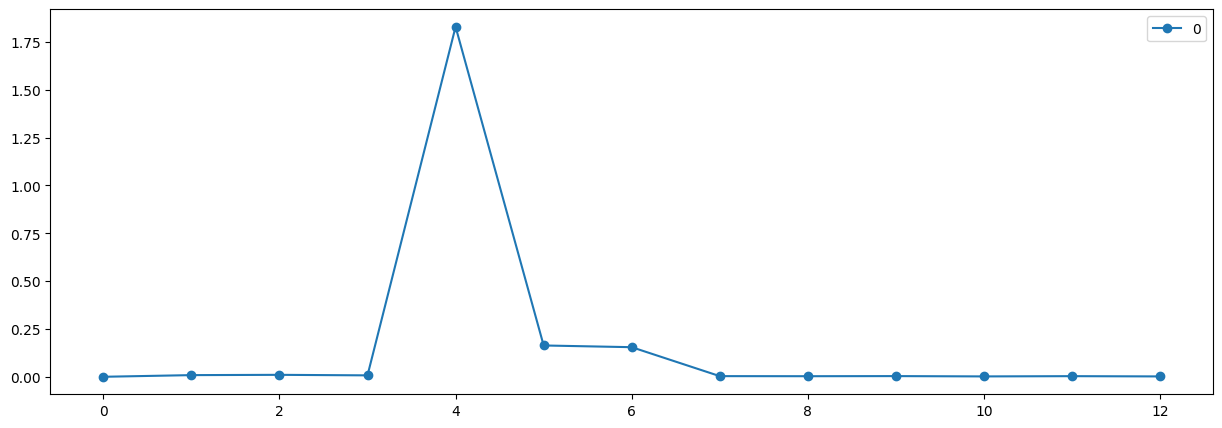

In [673]:
tdf = time_df.plot(figsize=(15,5), marker="o")

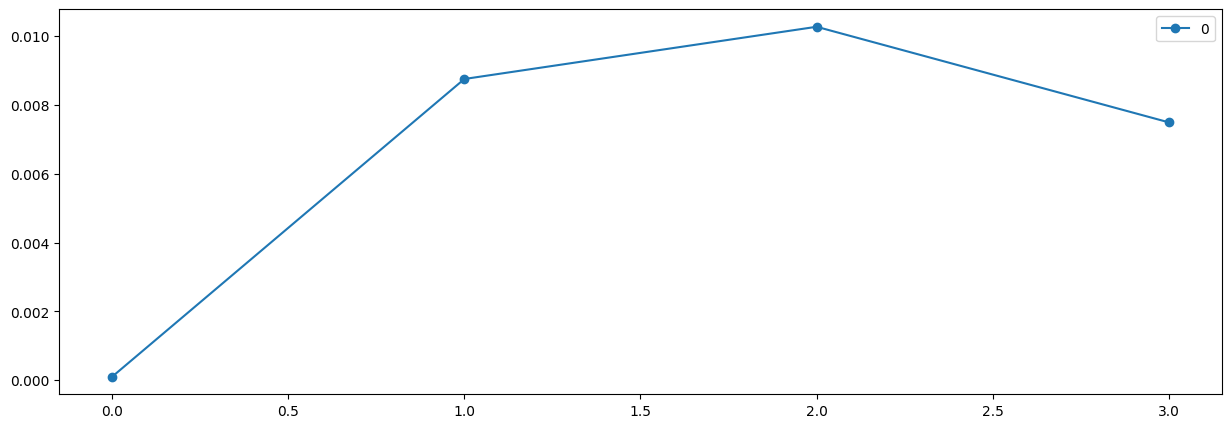

In [674]:
# Zoomed view
tdf = time_df[:4].plot(figsize=(15,5), marker="o")

In [675]:
# finding the index of that model which required the least time
min_time = min(Time)
print(Time.index(min_time))

0


### Based on computational time taken by each model, we see that the 0th model i.e. **Simple Linear Regression Model** required the least time. <br><br> **Observation** : Batch Gradient Descent proved to consume the maximum computational time.

## Performance Metric Analysis

### ***Mean-Squared Error Analysis***

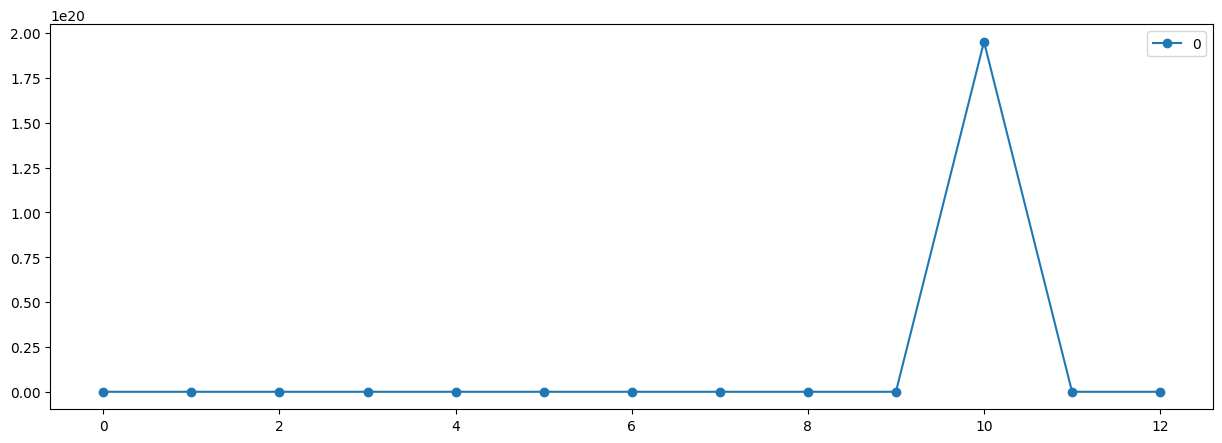

In [676]:
# Plotting the plot for the list of MSEs collected for all the models
msedf = mse_df.plot(figsize=(15,5), marker="o")

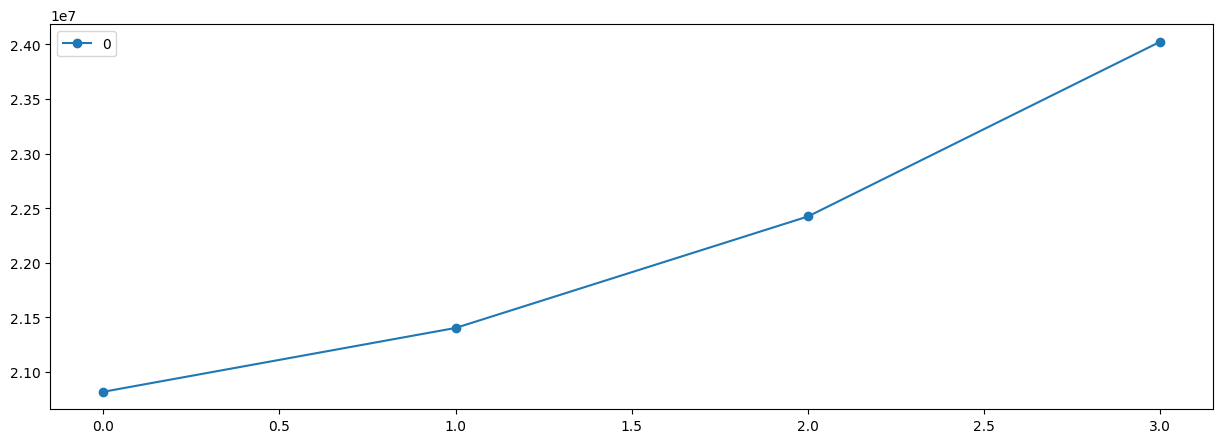

In [677]:
# Zoomed View
msedf = mse_df[:4].plot(figsize=(15,5), marker="o")

In [678]:
# finding the index of that model which has the least MSE
min_mse = min(MSE)
print(MSE.index(min_mse))

0


### Based on MSE-analysis by each model, we see that the 0th model i.e. **Simple Linear Regression Model** has the least MSE.

### ***Mean-Absolute Error Analysis***

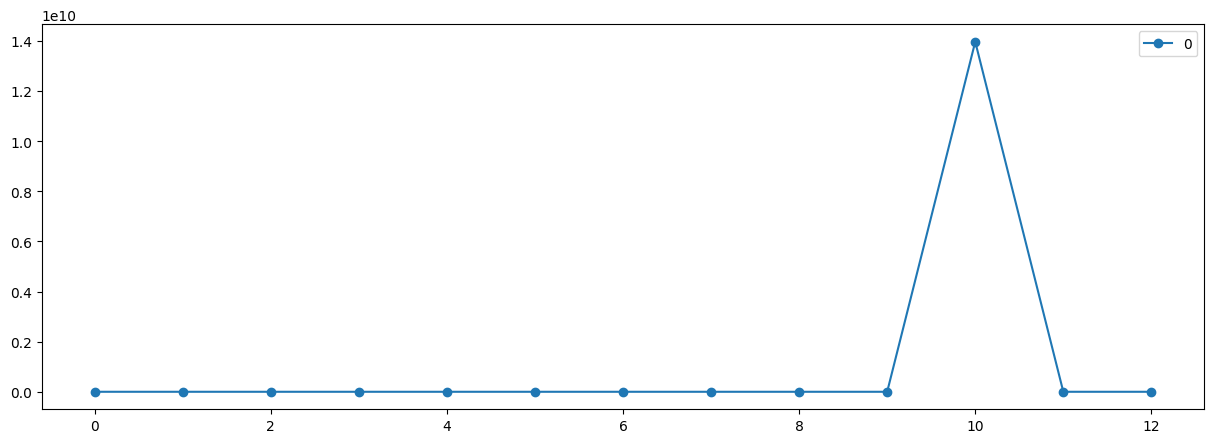

In [679]:
# Plotting the plot for the list of MAEs collected for all the models
maedf = mae_df.plot(figsize=(15,5), marker="o")

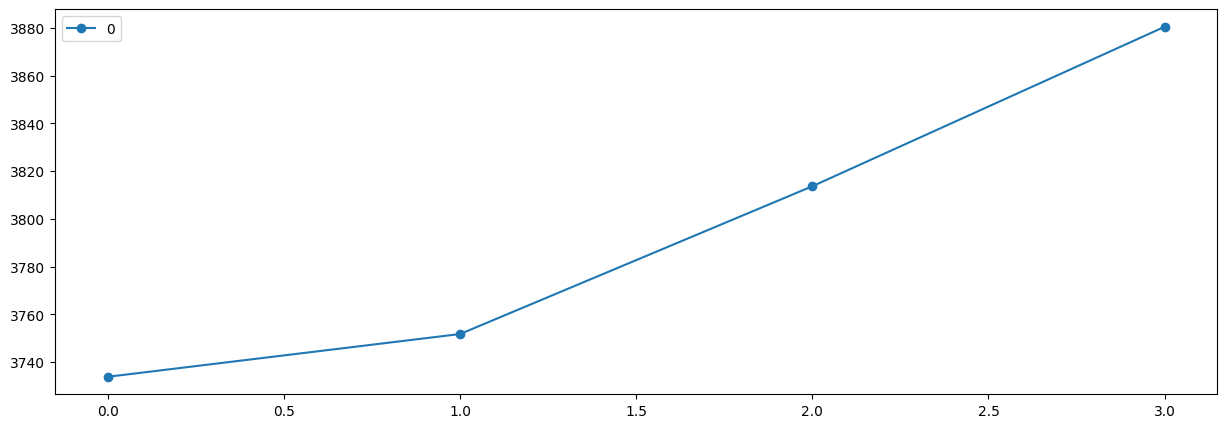

In [680]:
# Zoomed View
maedf = mae_df[:4].plot(figsize=(15,5), marker="o")

In [681]:
# finding the index of that model which has the least MAE
min_mae = min(MAE)
print(MAE.index(min_mae))

0


### Based on MAE-analysis by each model, we see that the 0th model i.e. **Simple Linear Regression Model** has the least MAE.

### ***R-Squared Error Analysis***

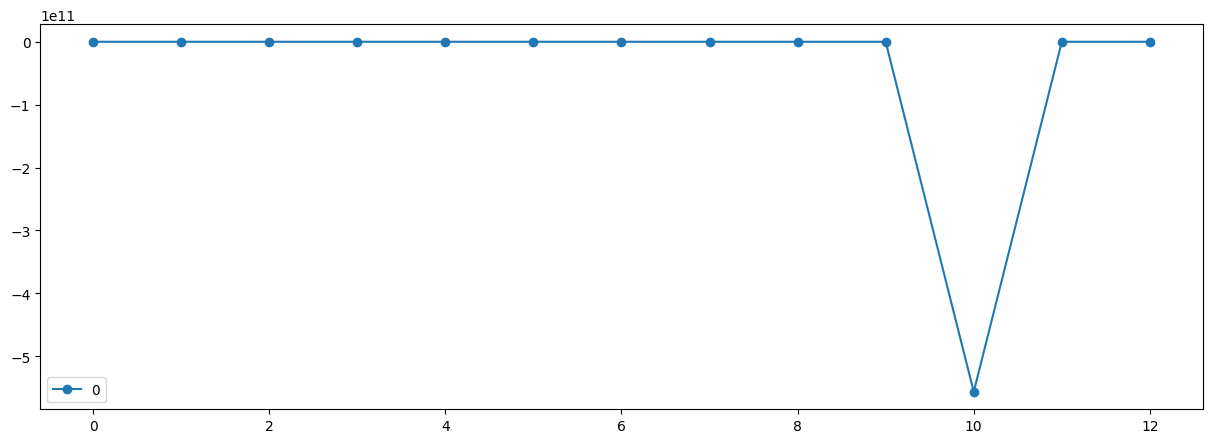

In [682]:
# Plotting the plot for the list of R-squared's collected for all the models
r2df = r2_df.plot(figsize=(15,5), marker="o")

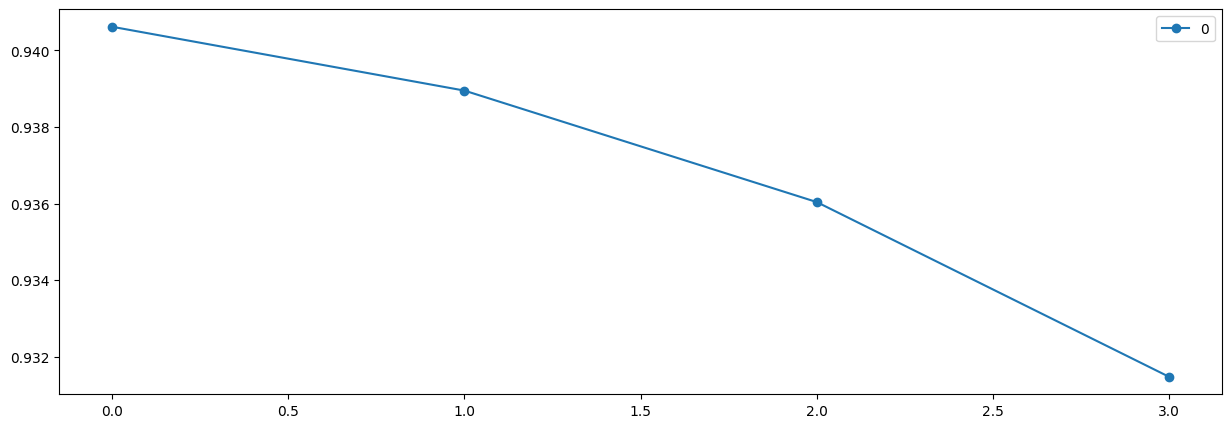

In [683]:
# Zoomed View
r2df = r2_df[:4].plot(figsize=(15,5), marker="o")

In [684]:
# finding the index of that model which has the maximum R-squared value
max_r2 = max(R2)
print(R2.index(max_r2))

0


### Based on R2-analysis by each model, we see that the 0th model i.e. **Simple Linear Regression Model** has the max R2-score.

# Conclusion
**Instruction:** Summarize the findings from the analysis, including which models performed best in terms of accuracy and computational efficiency.

In [685]:
pm_dict = {
    "Computation Time (in seconds)" : pd.Series(Time, index=list_of_models),
    "MSE" : pd.Series(MSE, index=list_of_models),
    "MAE" : pd.Series(MAE, index=list_of_models),
    "R^2-score" : pd.Series(R2, index=list_of_models)
}

In [686]:
# Printing the table of values of performance metrics for each model
pd.DataFrame(pm_dict)

,Computation Time (in seconds),MSE,MAE,R^2-score
SimpleLinearRegression,0.000101,2.081943e+07,3.733831e+03,9.406148e-01
PolynomialRegressionDegree2,0.008753,2.140368e+07,3.751751e+03,9.389483e-01
PolynomialRegressionDegree3,0.010271,2.242382e+07,3.813679e+03,9.360385e-01
PolynomialRegressionDegree4,0.007493,2.402308e+07,3.880501e+03,9.314768e-01
BatchGradientDescent,1.829672,4.242139e+08,1.670213e+04,-2.100242e-01
StochasticGradientDescent,0.163765,5.151510e+08,1.909783e+04,-4.694124e-01
MiniBatchGradientDescent,0.154779,6.712252e+09,7.976042e+04,-1.814597e+01
LassoRegression,0.003471,2.081981e+07,3.733885e+03,9.406138e-01
RidgeRegression,0.003065,2.082854e+07,3.735113e+03,9.405889e-01
ElasticNetRegression,0.003635,2.712775e+07,4.187097e+03,9.226211e-01


## **Summary of Findings from the Analysis**<br>

In this analysis, we compared the performance of three different models to predict the target variable based on the provided dataset: ***'SimpleLinearRegression', 'PolynomialRegressionDegree2', 'PolynomialRegressionDegree3', 'PolynomialRegressionDegree4', 'BatchGradientDescent', 'StochasticGradientDescent', 'MiniBatchGradientDescent', 'LassoRegression', 'RidgeRegression', 'ElasticNetRegression', 'EarlyStopping', 'NormalEquation' and 'SVD'.*** The evaluation metrics used to assess model performance were Mean Absolute Error (MAE), Mean Squared Error (MSE), R-squared (R²), and computational efficiency (measured by training time). The models were trained on 80% of the dataset and tested on the remaining 20%.

Best Performing Model : ***Simple Linear Regression***

**Model Performance:**

*Accuracy*: The R² value for the Simple Linear Regression model was 0.94, indicating that 94% of the variance in the target variable was explained by the features.<br>
*Error*: The MAE and RMSE were ***3733.83*** and ***4562.83***, respectively.<br>
*Computational Efficiency*: This model was the fastest to train, with a training time of only ***0.00010*** seconds.
*Conclusion*: Simple Linear Regression provided a quick, simple model but struggled to capture complex patterns in the data, as indicated by the relatively higher error rates.